In [35]:
%pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: D:\AI ML\venv\Scripts\python.exe -m pip install --upgrade pip


In [36]:
%pip install lxml # used to parse xml and html documents

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: D:\AI ML\venv\Scripts\python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [37]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import numpy as np

# if response code is 403
 - headers={'User-Agent':'Mozilla/5.0 (Windows NT 6.3; Win 64 ; x64) AppleWebKit /537.36 (KHTML, like Gecko) Chrome/80.0.3987.162 Safari/537.36'}
 - requests.get('url',headers=headers).text

Why it happens: Websites actively block automated bots to protect their servers, and they easily detect scrapers because the default Python requests library introduces itself as python-requests.

Why we use headers: By passing a custom User-Agent header, we override this default identifier and disguise our Python script as a legitimate human web browser (like Google Chrome).

In [38]:
headers = {'User-Agent':'Mozilla/5.0 (Windows NT 6.3; Win 64 ; x64) AppleWebKit /537.36 (KHTML, like Gecko) Chrome/80.0.3987.162 Safari/537.36'}

webpage = requests.get('https://www.ambitionbox.com/list-of-companies?page=1', headers=headers).text # entire html code of that webpage, just parse it now

In [39]:
soup=BeautifulSoup(webpage,'lxml')

In [40]:
#print(soup.prettify())

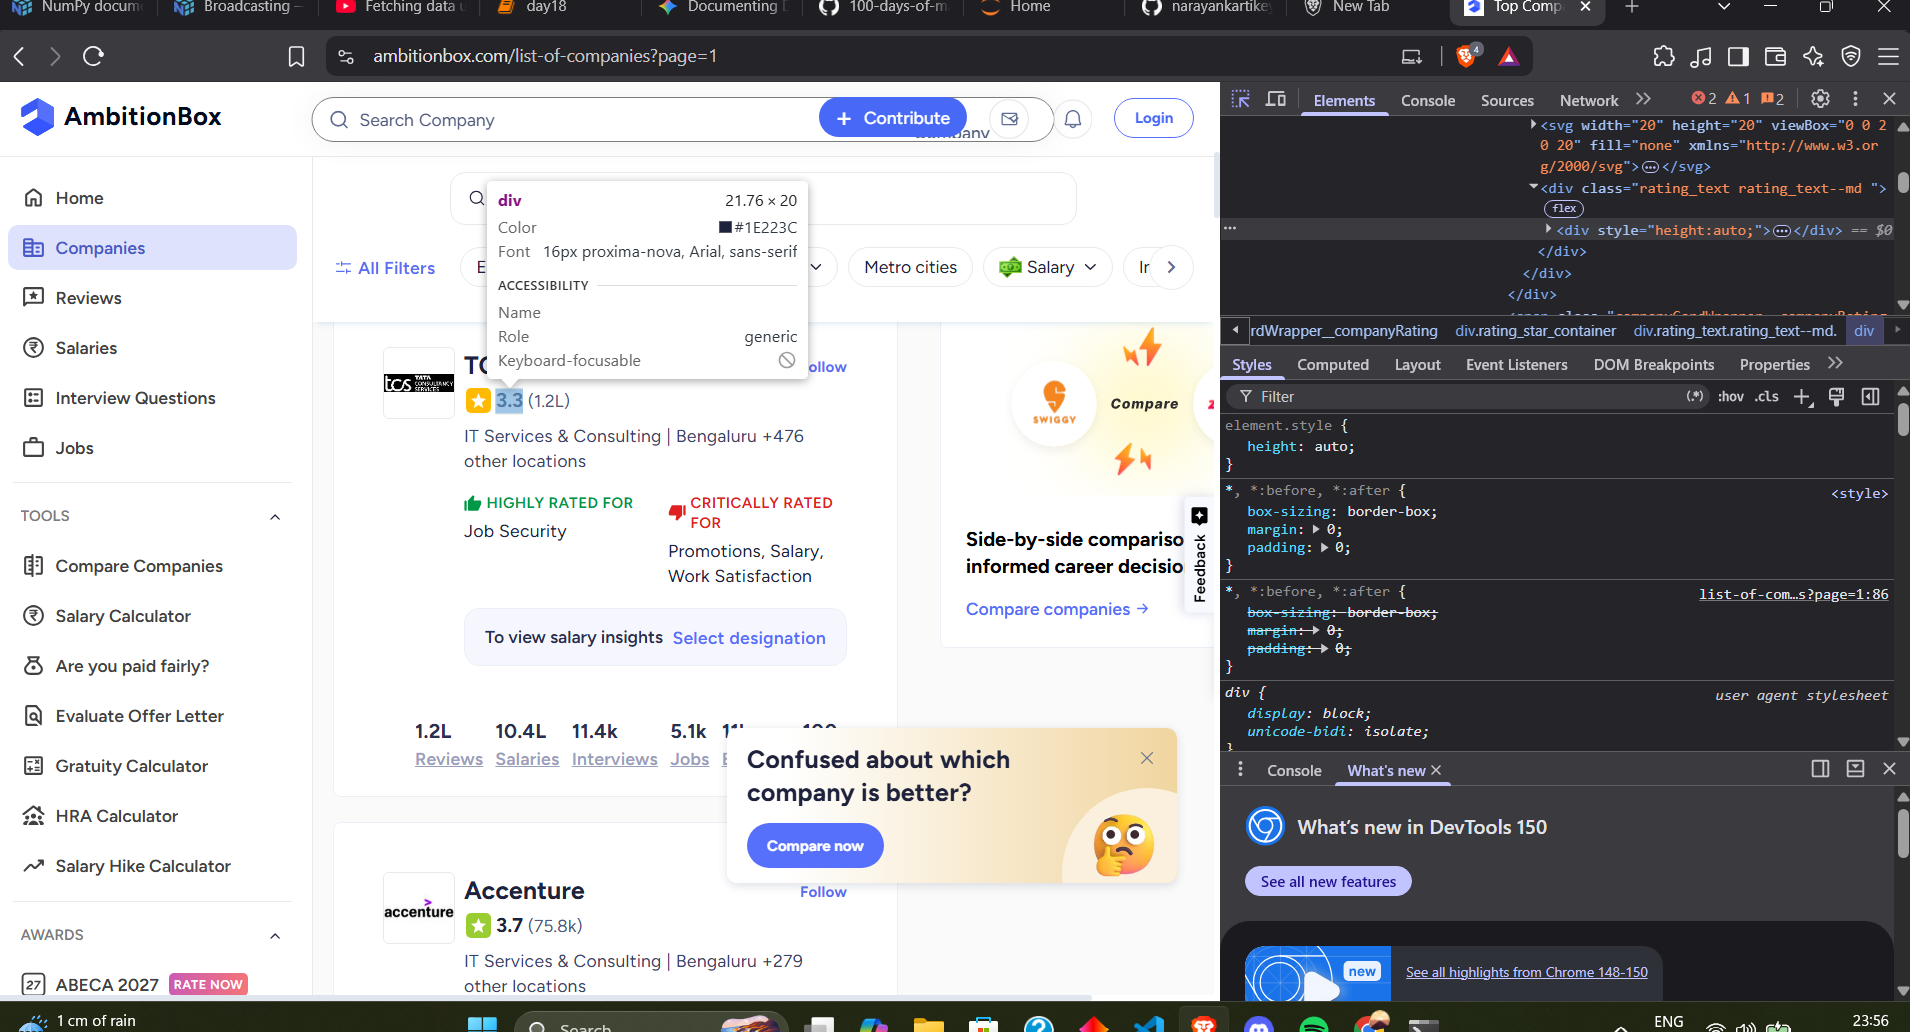

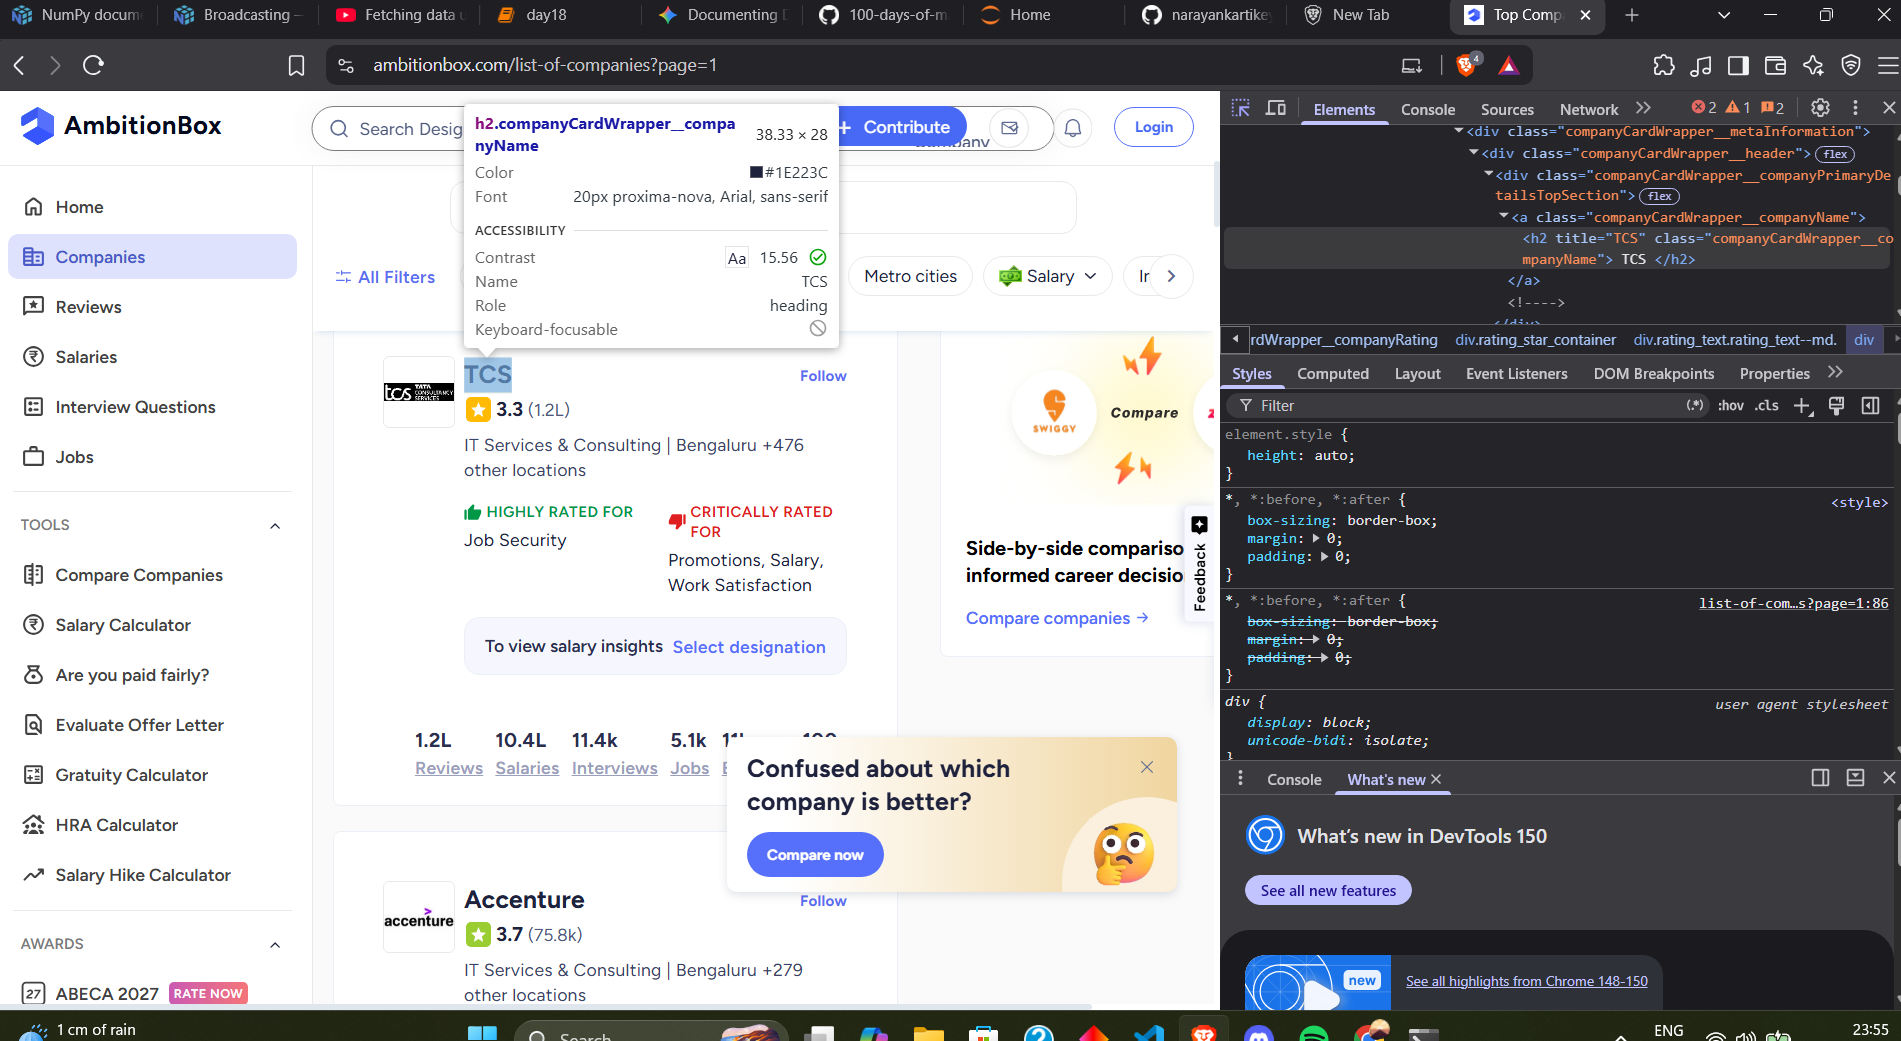

go to the webpage, click F12 and then 'select an element in the page to inspect it' and then click on the element which we want in our data and look at its html tag, but sometimes many features use the same tag!

In [41]:
soup.find_all('h1')[0].get_text(strip=True, separator=' ') # use .get_text... instead of .text to remove unwanted \t and \n

'Top Companies in INDIA'

In [42]:
soup.find_all('h2')
#len(soup.find_all('h2'))

[<h2 class="companyListing__title">
 								Companies in India
 							</h2>,
 <h2 class="companyCardWrapper__companyName" title="TCS">
 									TCS
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Accenture">
 									Accenture
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Wipro">
 									Wipro
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Cognizant">
 									Cognizant
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Capgemini">
 									Capgemini
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="HDFC Bank">
 									HDFC Bank
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Infosys">
 									Infosys
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="HCLTech">
 									HCLTech
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="ICICI Bank">
 									ICICI Bank
 								</h2>,
 <h2 class="companyCardWrapper__companyName" ti

## TO FIND OUT NAMES OF THE COMPANIES

In [43]:
for i in soup.find_all('h2'):
  print(i.text.strip())

Companies in India
TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Axis Bank
Jio
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTM Limited
HDB Financial Services
Popular Collections by Industries
Popular Collections by Cities
Popular Collections by Roles


In [44]:
for i in soup.find_all('p'):
  print(i.text.strip())

AmbitionBox
About Company
All rights reserved © 2026 Info Edge (India) Ltd.
Popular
AmbitionBox Award Winner'26
AmbitionBox Award Winner'26
AmbitionBox Award Winner'26
AmbitionBox Award Winner'26
Side-by-side comparison to make informed career
										decisions


In [47]:
for i in soup.find_all('p'):
  print(i.text.strip())

AmbitionBox
About Company
All rights reserved © 2026 Info Edge (India) Ltd.
Popular
AmbitionBox Award Winner'26
AmbitionBox Award Winner'26
AmbitionBox Award Winner'26
AmbitionBox Award Winner'26
Side-by-side comparison to make informed career
										decisions


## TO FIND OUT THE RATINGS

In [54]:
len(soup.find_all('span', class_='companyCardWrapper__companyRatingCount'))

20

## TO FIND OUT THE NUMBER OF REVIEWS

In [58]:
len(soup.find_all('span', class_='companyCardWrapper__ActionCount'))

120

## CONSIDERING THE WHOLE CONTAINER

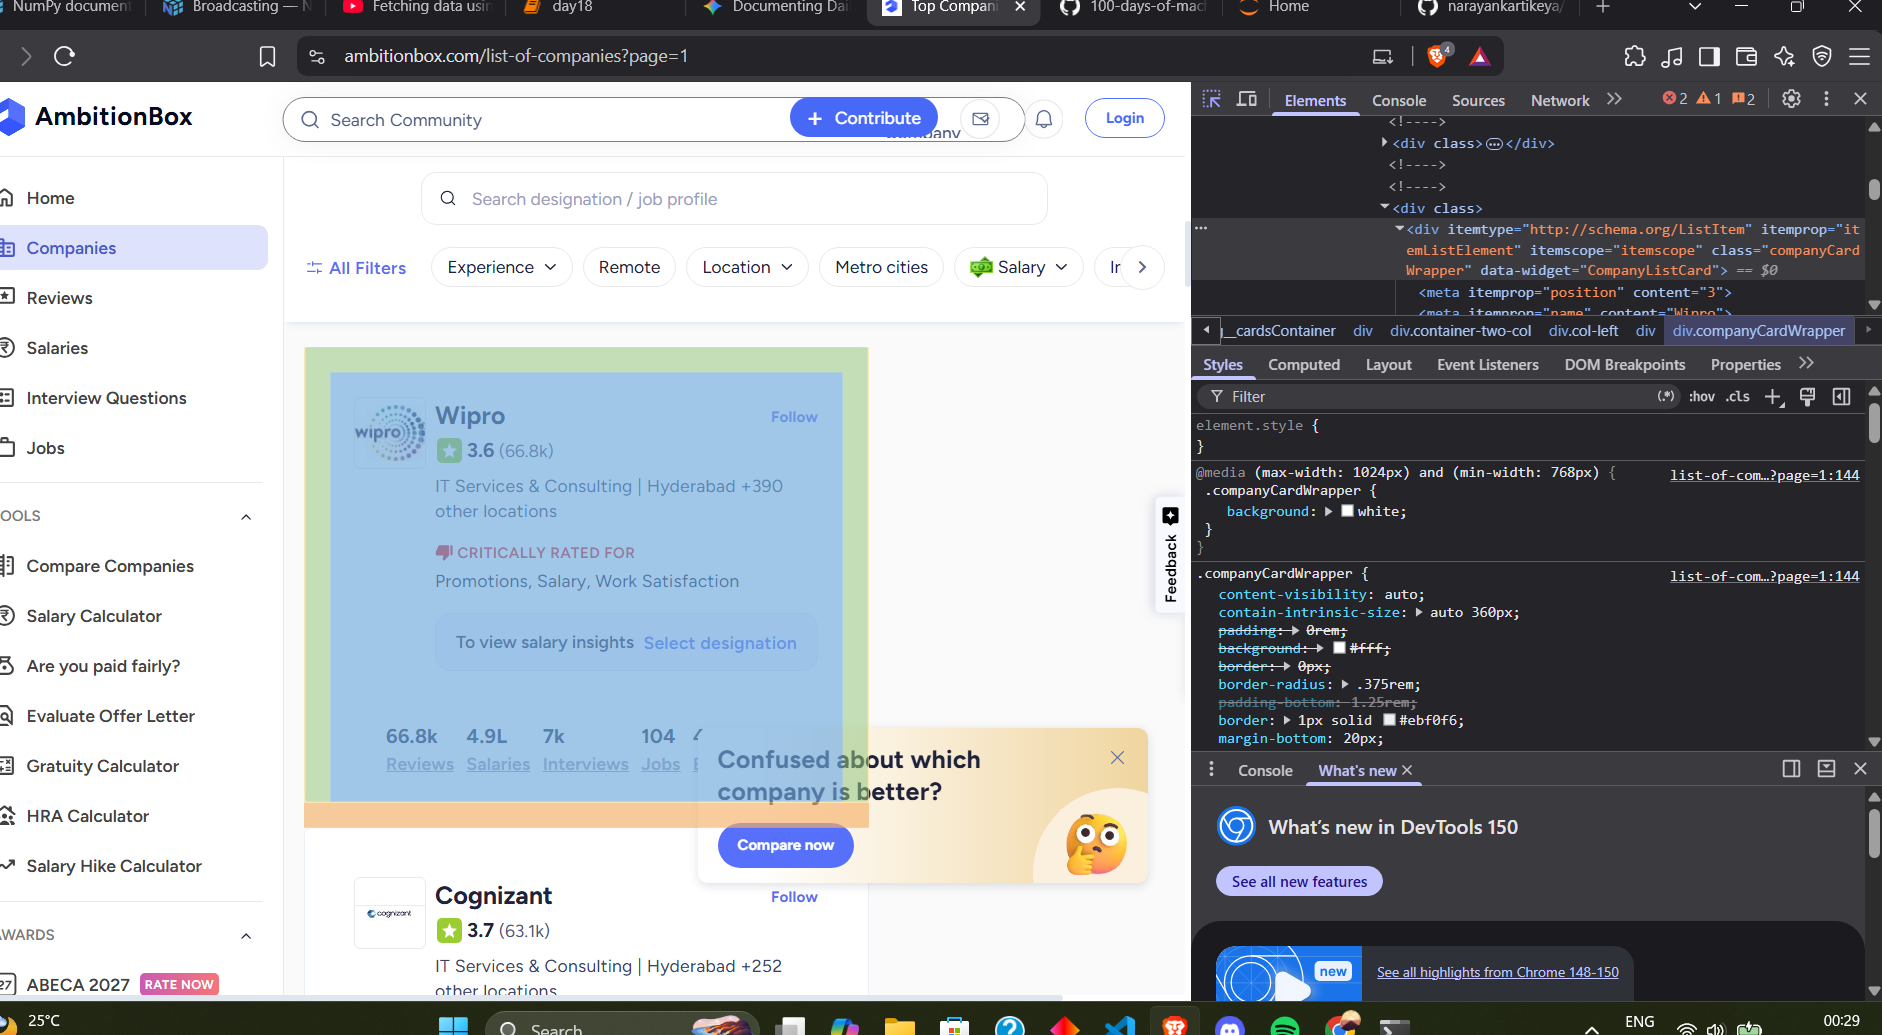

we should extract the entire div for each company, run a loop and then work one by one on each company extracting the features of each and storing it in a list

In [61]:
company=soup.find_all('div', class_='companyCardWrapper')

In [62]:
len(company) 

20

In [96]:
# (find_all returns a list - use when many features use same tag)

name = []
rating = []
reviews = []
ctype = []
hq = []
how_old = []
no_of_employee = []

for i in company:
    # 1. Company Name
    name_tag = i.find('h2', class_='companyCardWrapper__companyName')
    name.append(name_tag.text.strip() if name_tag else None)
    
    # 2. Rating 
    # Try the span first, if it fails, fallback to the main rating wrapper div
    rating_tag = i.find('span', class_='companyCardWrapper__companyRatingValue')
    if not rating_tag:
        rating_tag = i.find('div', class_='companyCardWrapper__companyRating')
    rating.append(rating_tag.text.strip() if rating_tag else None)
    
    # 3. Reviews (This was working for you!)
    review_tag = i.find('span', class_='companyCardWrapper__ActionCount')
    reviews.append(review_tag.text.strip() if review_tag else None)
    
    # 4. Info Entities (Type, HQ, Age, Employees are now grouped together!)
    interlinking_tag = i.find('span', class_='companyCardWrapper__interLinking')
    
    if interlinking_tag:
        # Get the string and split it into a list wherever there is a '|'
        raw_string = interlinking_tag.text.strip()
        info_list = [item.strip() for item in raw_string.split('|')]
        
        # Assign pieces based on how many exist (some companies miss data)
        ctype.append(info_list[0] if len(info_list) > 0 else None)
        hq.append(info_list[1] if len(info_list) > 1 else None)
        how_old.append(info_list[2] if len(info_list) > 2 else None)
        no_of_employee.append(info_list[3] if len(info_list) > 3 else None)
    else:
        # If the tag is missing entirely, append None to keep the dataframe balanced
        ctype.append(None)
        hq.append(None)
        how_old.append(None)
        no_of_employee.append(None)

# Create the DataFrame
df = pd.DataFrame({
    'name': name,
    'rating': rating,
    'reviews': reviews,
    'company_type': ctype,
    'Head_Quarters': hq,
    'Company_Age': how_old, # data removed from website
    'No_of_Employee': no_of_employee, # data removed from website
})

# 1. Set the last two columns explicitly to NaN
df['Company_Age'] = np.nan
df['No_of_Employee'] = np.nan
# 2. Drop columns (axis=1) where ALL values are NaN
df = df.dropna(axis=1, how='all')

df

,name,rating,reviews,company_type,Head_Quarters
0,TCS,3.3,1.2L,IT Services & Consulting,Bengaluru +476 other locations
1,Accenture,3.7,75.8k,IT Services & Consulting,Bengaluru +279 other locations
2,Wipro,3.6,66.8k,IT Services & Consulting,Hyderabad +390 other locations
3,Cognizant,3.7,63.1k,IT Services & Consulting,Hyderabad +252 other locations
4,Capgemini,3.6,55.2k,IT Services & Consulting,Bengaluru +204 other locations
5,HDFC Bank,3.8,54.4k,Banking,Mumbai +1894 other locations
6,Infosys,3.5,50.2k,IT Services & Consulting,Bengaluru +257 other locations
7,HCLTech,3.4,47.4k,IT Services & Consulting,Chennai +248 other locations
8,ICICI Bank,4.0,47k,Banking,Mumbai +1470 other locations
9,Tech Mahindra,3.3,44.6k,IT Services & Consulting,Hyderabad +338 other locations


In [97]:
name

['TCS',
 'Accenture',
 'Wipro',
 'Cognizant',
 'Capgemini',
 'HDFC Bank',
 'Infosys',
 'HCLTech',
 'ICICI Bank',
 'Tech Mahindra',
 'Genpact',
 'TP',
 'Axis Bank',
 'Jio',
 'Concentrix Corporation',
 'Amazon',
 'Reliance Retail',
 'iEnergizer',
 'LTM Limited',
 'HDB Financial Services']

In [98]:
rating

['3.3',
 '3.7',
 '3.6',
 '3.7',
 '3.6',
 '3.8',
 '3.5',
 '3.4',
 '4.0',
 '3.3',
 '3.6',
 '3.9',
 '3.6',
 '4.4',
 '3.5',
 '3.9',
 '3.9',
 '4.5',
 '3.6',
 '3.9']

In [99]:
reviews


['1.2L',
 '75.8k',
 '66.8k',
 '63.1k',
 '55.2k',
 '54.4k',
 '50.2k',
 '47.4k',
 '47k',
 '44.6k',
 '43.8k',
 '40k',
 '34.4k',
 '34.2k',
 '33.1k',
 '32.6k',
 '28k',
 '27.8k',
 '27.3k',
 '26.5k']

In [100]:
ctype

['IT Services & Consulting',
 'IT Services & Consulting',
 'IT Services & Consulting',
 'IT Services & Consulting',
 'IT Services & Consulting',
 'Banking',
 'IT Services & Consulting',
 'IT Services & Consulting',
 'Banking',
 'IT Services & Consulting',
 'Analytics & KPO',
 'BPO',
 'Banking',
 'Telecom',
 'BPO',
 'Internet',
 'Retail',
 'BPO',
 'IT Services & Consulting',
 'NBFC']

In [101]:
hq

['Bengaluru +476 other locations',
 'Bengaluru +279 other locations',
 'Hyderabad +390 other locations',
 'Hyderabad +252 other locations',
 'Bengaluru +204 other locations',
 'Mumbai +1894 other locations',
 'Bengaluru +257 other locations',
 'Chennai +248 other locations',
 'Mumbai +1470 other locations',
 'Hyderabad +338 other locations',
 'Hyderabad +186 other locations',
 'Mumbai +266 other locations',
 'Mumbai +1561 other locations',
 'Mumbai +1980 other locations',
 'Bengaluru +193 other locations',
 'Bengaluru +553 other locations',
 'Mumbai +1179 other locations',
 'Noida +55 other locations',
 'Bengaluru +154 other locations',
 'Mumbai +1113 other locations']

In [102]:
how_old

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [103]:
no_of_employee

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [104]:
df.shape

(20, 5)

## Creating dataframe for all the pages

In [110]:
import time

In [116]:
# Create an empty list to hold the dataframes from each page
df_list = []
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

# LOOP 1: Iterate through the webpage pages (Page 1 to 10  only for this example)
for j in range(1, 11):
    
    # 1. Make the request and parse the HTML
    url = f'https://www.ambitionbox.com/list-of-companies?page={j}' # url changes with each page
    webpage = requests.get(url, headers=headers).text
    soup = BeautifulSoup(webpage, 'lxml')
    
    # 2. Find all company chunks on the current page
    company = soup.find_all('div', class_='companyCardWrapper')
    
    # 3. Create fresh, empty lists for the CURRENT page
    name, rating, reviews, ctype, hq, how_old, no_of_employee = [], [], [], [], [], [], []

    # LOOP 2: Iterate through each company on the current page
    for i in company:
        
        # Try/Except Block Example
        try:
            name.append(i.find('h2', class_='companyCardWrapper__companyName').text.strip())
        except:
            name.append(np.nan)

        try:
            rating.append(i.find('span', class_='companyCardWrapper__companyRatingValue').text.strip())
        except:
            rating.append(np.nan)
            
        try:
            reviews.append(i.find('span', class_='companyCardWrapper__ActionCount').text.strip())
        except:
            reviews.append(np.nan)

        # Handling the mashed-up text
        try:
            raw_string = i.find('span', class_='companyCardWrapper__interLinking').text.strip()
            info = [item.strip() for item in raw_string.split('|')]
            
            ctype.append(info[0] if len(info) > 0 else np.nan)
            hq.append(info[1] if len(info) > 1 else np.nan)
            how_old.append(info[2] if len(info) > 2 else np.nan)
            no_of_employee.append(info[3] if len(info) > 3 else np.nan)
        except:
            ctype.append(np.nan)
            hq.append(np.nan)
            how_old.append(np.nan)
            no_of_employee.append(np.nan)

    # 4. Create a DataFrame for the current page
    df = pd.DataFrame({
        'name': name,
        'rating': rating,
        'reviews': reviews,
        'company_type': ctype,
        'Head_Quarters': hq,
        'Company_Age': how_old,
        'No_of_Employee': no_of_employee,
    })
    
    # 5. Append this page's DataFrame to our master list
    df_list.append(df)
    
    # 6. Pause before hitting the next page
    time.sleep(2)

# 7. Merge all the dataframes in the list into one massive table
final = pd.concat(df_list, ignore_index=True)

In [117]:
df

,name,rating,reviews,company_type,Head_Quarters,Company_Age,No_of_Employee
0,Hindalco Industries,NaN,4.3k,Metals & Mining,Sambalpur +133 other locations,NaN,NaN
1,Bajaj Auto,NaN,4.3k,Automobile,Pune +333 other locations,NaN,NaN
2,LG Electronics,NaN,4.3k,Consumer Electronics & Appliances,Pune +308 other locations,NaN,NaN
3,HDFC ERGO General Insurance,NaN,4.2k,Insurance,Mumbai +333 other locations,NaN,NaN
4,DCB Bank,NaN,4.2k,Banking,Mumbai +355 other locations,NaN,NaN
5,Kogta Financial India Limited,NaN,4.2k,NBFC,Jaipur +260 other locations,NaN,NaN
6,RBL Bank,NaN,4.2k,Banking,Mumbai +301 other locations,NaN,NaN
7,Royal Enfield,NaN,4.2k,Automobile,Chennai +383 other locations,NaN,NaN
8,John Deere,NaN,4.2k,Industrial Machinery,Pune +160 other locations,NaN,NaN
9,Cloudnine Hospital,NaN,4.1k,Healthcare,Bengaluru +47 other locations,NaN,NaN


In [118]:
df.shape

(20, 7)

In [119]:
final.shape

(200, 7)